# 🔬 Análisis de Datos Magnetotelúricos
---
**Curso:** Magnetotelúrica desde Cero: Fundamentos, Procesamiento e Interpretación de Datos  
**Módulo 3 — Análisis e Interpretación de Datos MT**

Este notebook cubre el análisis de los datos MT procesados:
1. **Profundidad de investigación** (penetration depth).
2. **Tensor de impedancia:** estructura, componentes y dimensionalidad.
3. **Tensor de fase:** mapas para análisis de dimensionalidad 1D/2D/3D.
4. **Strike geoeléctrico:** dirección preferida de las estructuras geológicas.

> **Prerequisito:** haber ejecutado los Notebooks Visualización y Preprocesamiento.

## Pseudosección de resistividad aparente y fase

Los mapas de pseudosección muestran la variación de la resistividad aparente y fase desde periodos bajos hasta periodos altos.

In [1]:
# Importar librerías
from pathlib import Path
from mtpy import MT, MTData, MTCollection
import h5py
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path
from mtpy import MT, MTData, MTCollection

edi_path = Path("Edi_procesado")
h5_out = Path("h5_procesado") / "collection_procesado_interpolado.h5"

# borrar el archivo si ya existe
if h5_out.exists():
    h5_out.unlink()

# 1) construir un MTData desde los EDI procesados
md = MTData()

for fn in MTCollection.make_file_list(edi_path, file_types=["edi"]):
    mt_obj = MT(fn)
    mt_obj.read()
    md.add_station(mt_obj)

# 2) escribir un nuevo H5 limpio
with MTCollection() as mc:
    mc.open_collection(h5_out)
    mc.from_mt_data(md)

# 3) abrirlo de nuevo para análisis
with MTCollection() as mc:
    mc.open_collection(h5_out)
    mtd = mc.to_mt_data()

print("H5 reconstruido correctamente:", h5_out)
print("Número de estaciones:", len(mtd.mt_list))

26:03:17T09:38:26 | INFO | line:685 |mth5.mth5 | _initialize_file | Initialized MTH5 0.2.0 file h5_procesado\collection_procesado_interpolado.h5 in mode a
26:03:17T09:38:26 | WARNING | line:1086 |mth5.mth5 | get_survey | /Experiment/Surveys/edi does not exist, check survey_list for existing names.
26:03:17T09:38:27 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.MC0001
26:03:17T09:38:28 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.MC0006
26:03:17T09:38:28 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.MC0007
26:03:17T09:38:28 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.MC0008
26:03:17T09:38:28 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.MC0009
26:03:17T09:38:29 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.MC0010
26:03:17T09:38:29 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.MC0011
26:03:17T09:38:

In [4]:
# Convertir a MTData
with MTCollection() as mc:
    mc.open_collection(Path("h5_procesado\collection_procesado_interpolado.h5")) # Ruta del h5 procesado
    mtd = mc.to_mt_data()

26:03:17T09:39:46 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado_interpolado.h5


In [ ]:
mc.close_collection() # cerrar MTCollection una vez creado el MTData para evitar daños

Para graficar la pseudosección se debe definir el datum del área de estudio.

In [5]:
mtd.utm_crs = 9377 # Se define el datum de la zona
mtd.utm_crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

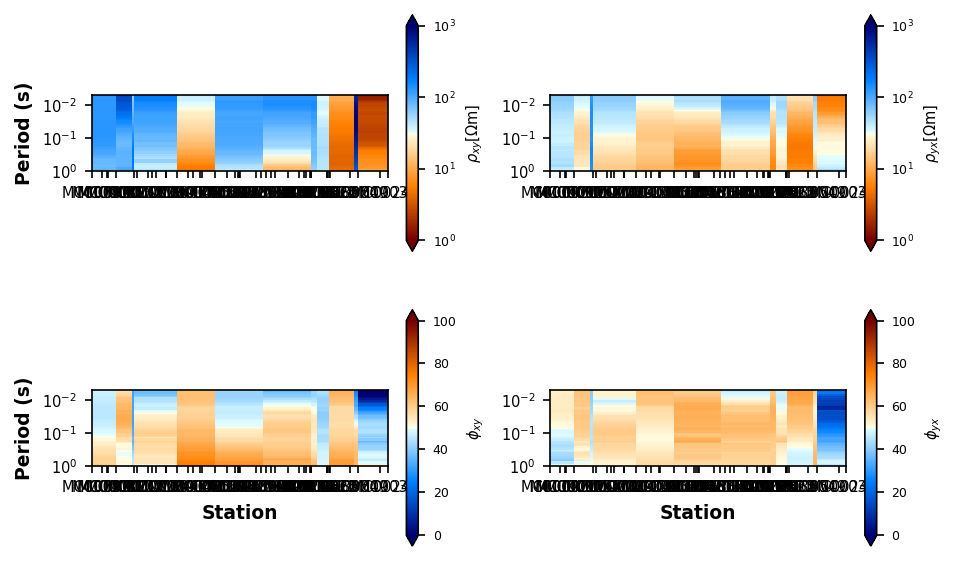

In [6]:
rpp_plot = mtd.plot_resistivity_phase_pseudosections(y_stretch=1200)

## Mapa de profundidad de investigación por periodos

Los mapas de profundidad de investigación por periodo muestran a qué profundidad son sensibles las mediciones. Para el cálculo de la profundidad de investigación de cada estación en un único periodo se utiliza una aproximación de Niblett-Bostick.

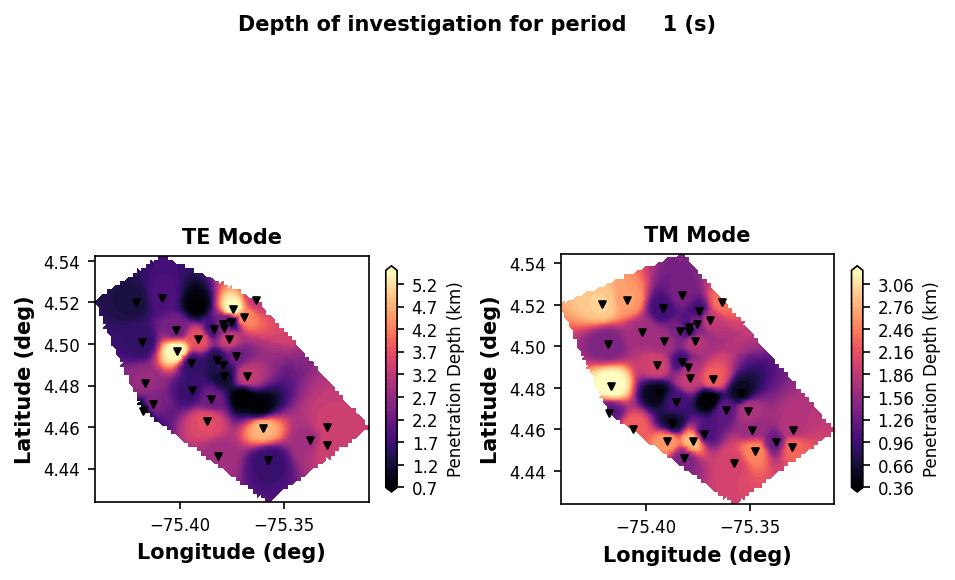

In [13]:
depth_of_penetration = mtd.plot_penetration_depth_map(plot_det=False)

Mapa de profundidad de investigación a 1 segundo

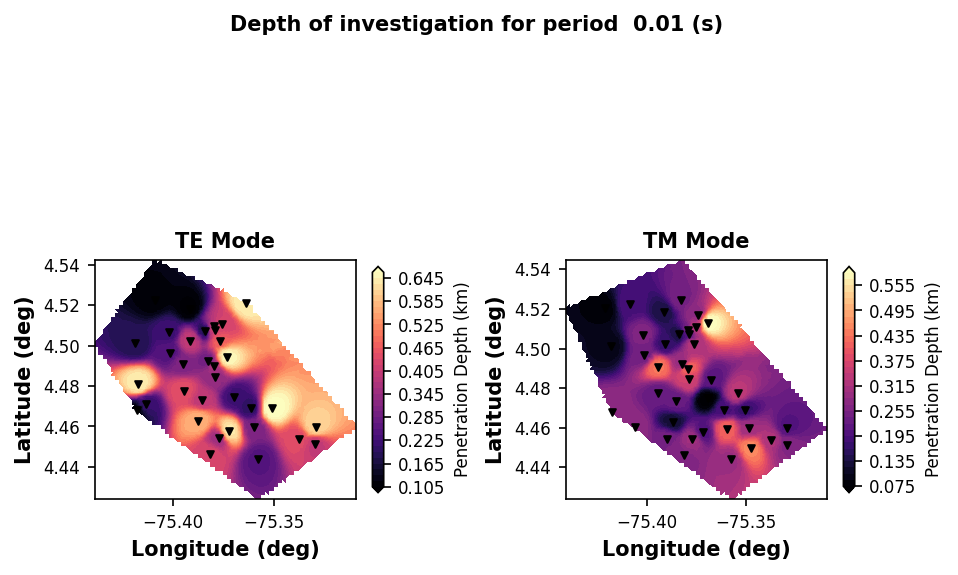

In [14]:
depth_of_penetration.plot_period = 0.01 # cambiar el periodo que se quiere visualizar
depth_of_penetration.redraw_plot()

Mapa de profundidad de investigación a 0.01 segundos

## Profundidad de investigación en un sondeo

Se grafica la profundidad de investigación de un sondeo específico.

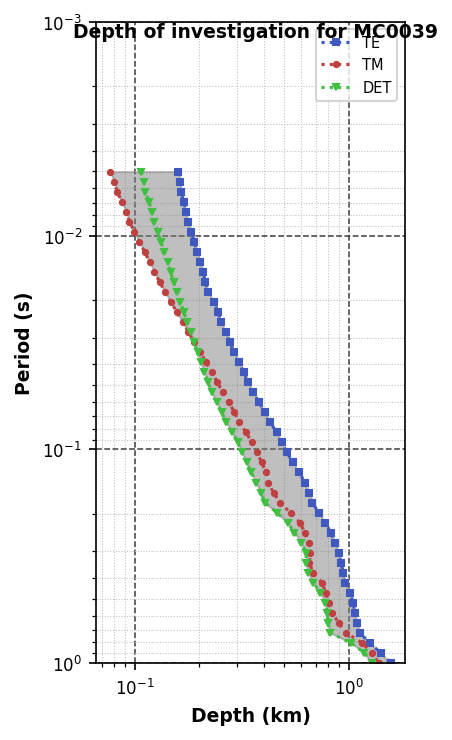

Plotting PlotPenetrationDepth1D

In [23]:
stationn="edi.MC0039"  # Cambiar el nombre de la estación
mtd.plot_penetration_depth_1d(station_key=stationn)

## Análisis de dimensionalidad

### Mapa de estaciones

26:03:17T09:44:56 | WARNING | line:163 |mtpy.imaging.plot_stations | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/13/3992/2379


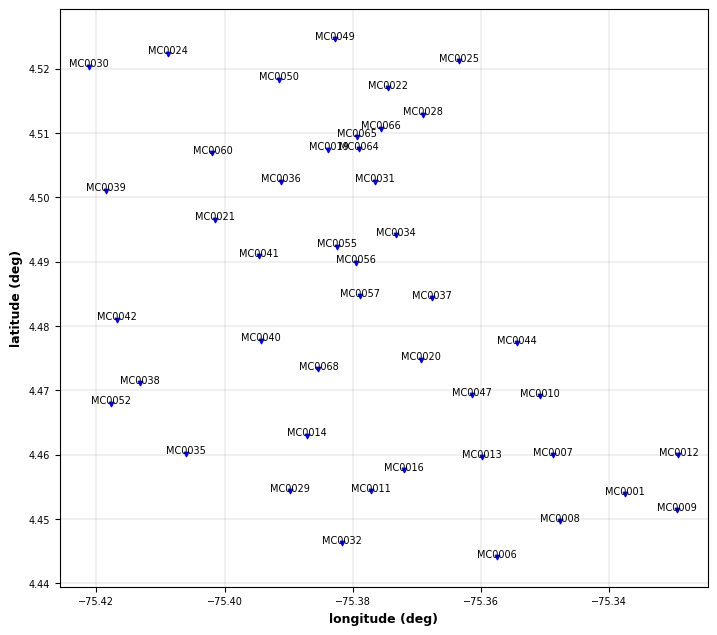

In [24]:
plt.figure(figsize=(8, 10))

mtd.plot_stations(marker_size=10, label_fontsize= 50)

plt.show()

### Mapa de tensor de fase por periodos

Los mapas de tensor de fase son un indicativo de la dimensionalidad del área a diferentes periodos.

26:03:17T09:56:23 | WARNING | line:794 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/13/3992/2379


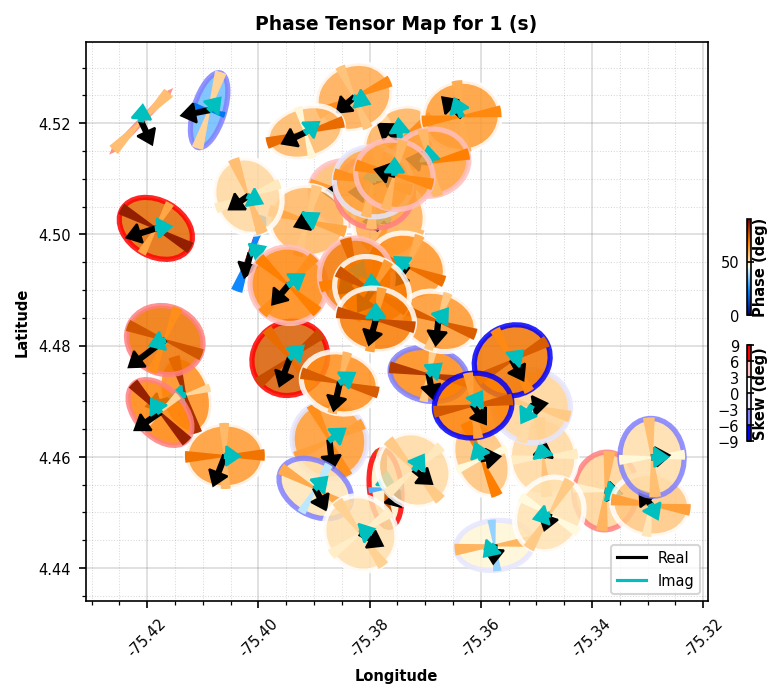

In [29]:
pt_map = mtd.plot_phase_tensor_map(
    plot_tipper="yri", 
    ellipse_size=.007,
    arrow_size=.007
)

### Mapa de tensor de fase a 0.01 segundos

26:03:17T09:57:22 | WARNING | line:794 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/13/3992/2379


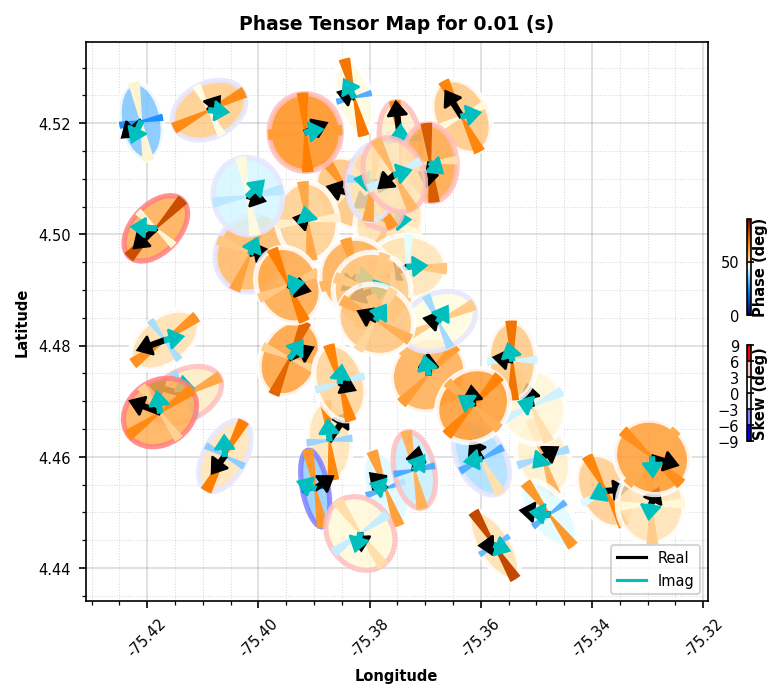

In [31]:
pt_map.plot_period = 0.01 # especificar el periodo que se quiere visualizar
pt_map.redraw_plot()

### Mapa de tensor de fase a 0.1 segundos

26:03:17T09:58:57 | WARNING | line:794 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/13/3992/2379


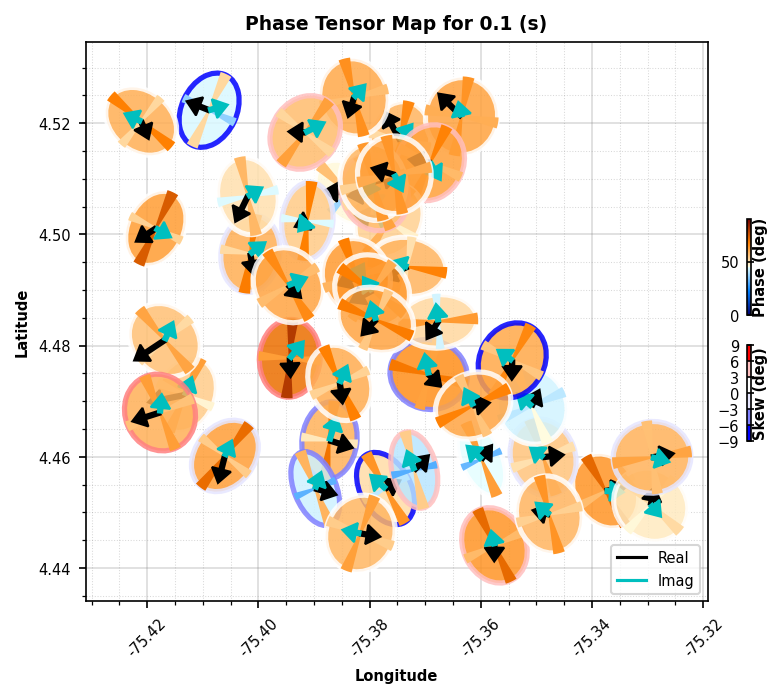

In [35]:
pt_map.plot_period = 0.1 # especificar el periodo que se quiere visualizar
pt_map.redraw_plot()

## Componentes del tensor de fase por sondeo

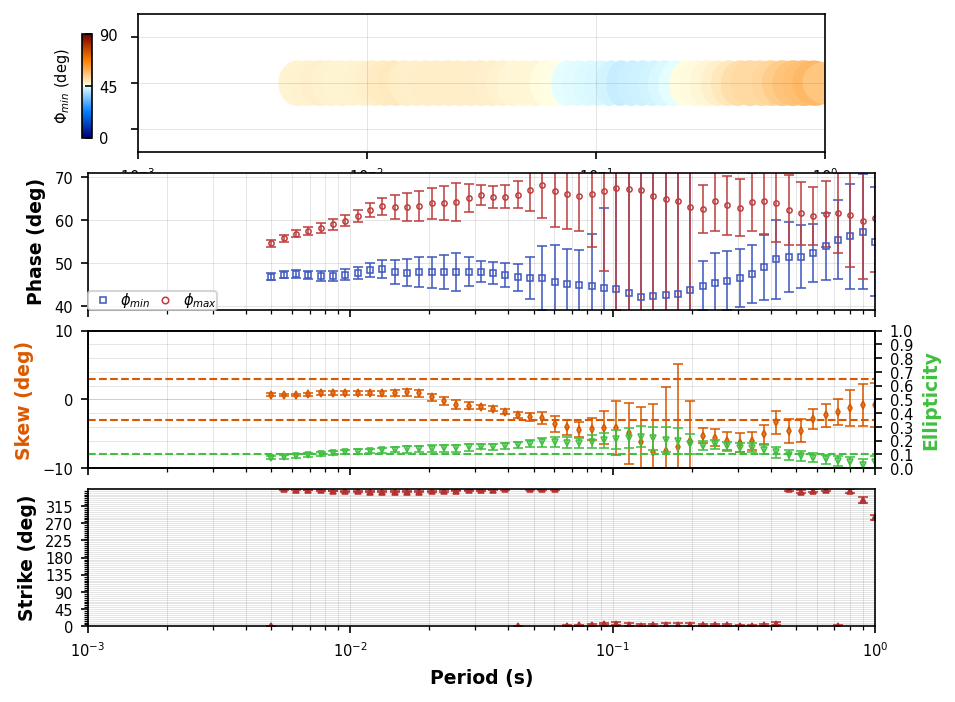

In [39]:
try:
    mtd.plot_phase_tensor("edi.MC0036") # Cambiar el nombre de la estación que se desea visualizar
except:
    pass

## Pseudosección del tensor de fase para todas las estaciones

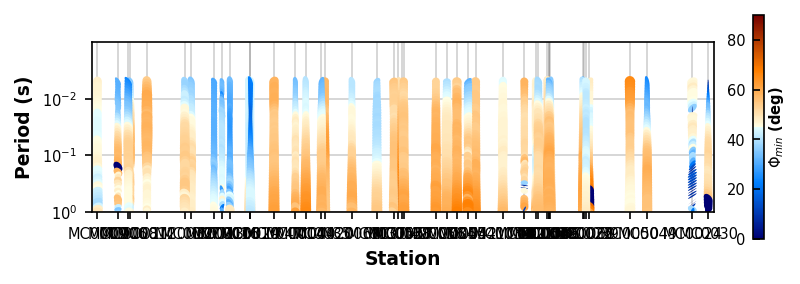

In [41]:
ptps_plot = mtd.plot_phase_tensor_pseudosection(x_stretch=10)
# Con esta línea se grafica la pseudosección del tensor de fase para todas las estaciones, si son más de 40 se tarda en ejecutar.

## Pseudosección del tensor de fase en un perfil

Abrir el h5 procesado para graficar el perfil

In [135]:
mc = MTCollection()
mc.open_collection(Path("h5_procesado\collection_procesado_interpolado.h5")) 

Definir el punto inicial y punto final del perfil y graficar

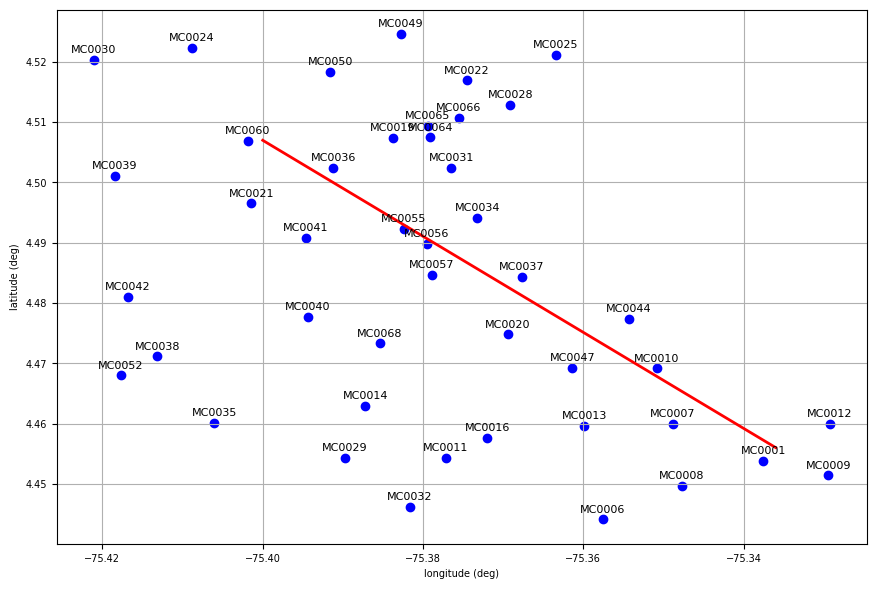

In [136]:
data_plot = [np.array(mc.dataframe["station"]), np.array(mc.dataframe["latitude"]), np.array(mc.dataframe["longitude"])]

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(data_plot[2], data_plot[1], color="b")

ax.plot([-75.400, -75.336], [4.507, 4.456], color='red', linestyle='-', linewidth=2) # Aquí se especifican las coordenadas del perfil

ax.set_xlabel('longitude (deg)')
ax.set_ylabel('latitude (deg)')

for i, name in enumerate(data_plot[0]):
    ax.annotate(name, (data_plot[2][i], data_plot[1][i]), 
                textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, color='black')

plt.grid(True)
plt.show()

In [137]:
# Calcular el rumbo del perfil

angulo = np.arctan((-75.400 + 75.336)/(4.507-4.456))*(180/np.pi)
print(angulo+360)

308.5504652961542


In [138]:
mc.close_collection() # una vez graficado el perfil cerramos la colección para evitar daños

26:03:17T14:54:04 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado_interpolado.h5


Se debe crear una copia al MTData para general el perfil solo con la información de los sondeos del perfil.

In [139]:
mtd_copy = mtd.copy()

In [140]:
interp_periods = np.logspace(np.log10(0.001), np.log10(1000), 80)
# Interpolación de los datos de cada estación
interp_mt_data = mtd_copy.interpolate(interp_periods, inplace=False)

In [141]:
interp_mt_data.utm_crs = 9377

In [142]:
# Se genera los datos del perfil con los datos interpolados
lon1, lat1 = -75.400, 4.507
lon2, lat2 = -75.336, 4.456

ax.plot([lon1, lon2], [lat1, lat2], color='red', linestyle='-', linewidth=2)

profile_mt_data = interp_mt_data.get_profile(lon1, lat1, lon2, lat2, 500)

In [143]:
print(len(profile_mt_data)) # imprime cuántas estaciones tomó el perfil
profile_mt_data

10


MTData([('edi.MC0030',
         TF( survey='edi', station='MC0030', latitude=4.52, longitude=-75.42, elevation=2444.00 )),
        ('edi.MC0060',
         TF( survey='edi', station='MC0060', latitude=4.51, longitude=-75.40, elevation=2112.00 )),
        ('edi.MC0036',
         TF( survey='edi', station='MC0036', latitude=4.50, longitude=-75.39, elevation=2318.00 )),
        ('edi.MC0055',
         TF( survey='edi', station='MC0055', latitude=4.49, longitude=-75.38, elevation=2514.00 )),
        ('edi.MC0056',
         TF( survey='edi', station='MC0056', latitude=4.49, longitude=-75.38, elevation=2506.00 )),
        ('edi.MC0057',
         TF( survey='edi', station='MC0057', latitude=4.48, longitude=-75.38, elevation=2523.00 )),
        ('edi.MC0037',
         TF( survey='edi', station='MC0037', latitude=4.48, longitude=-75.37, elevation=2719.00 )),
        ('edi.MC0010',
         TF( survey='edi', station='MC0010', latitude=4.47, longitude=-75.35, elevation=2098.00 )),
        ('edi.MC

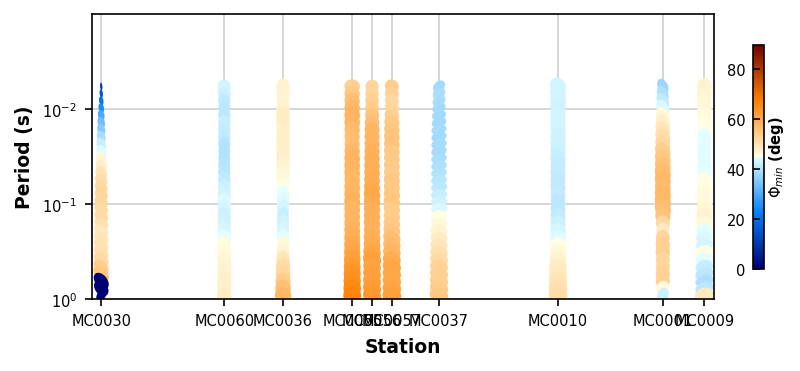

In [144]:
ptps_plot = profile_mt_data.plot_phase_tensor_pseudosection(x_stretch=5)

Pseudosección de resistividad aparente y fase del perfil

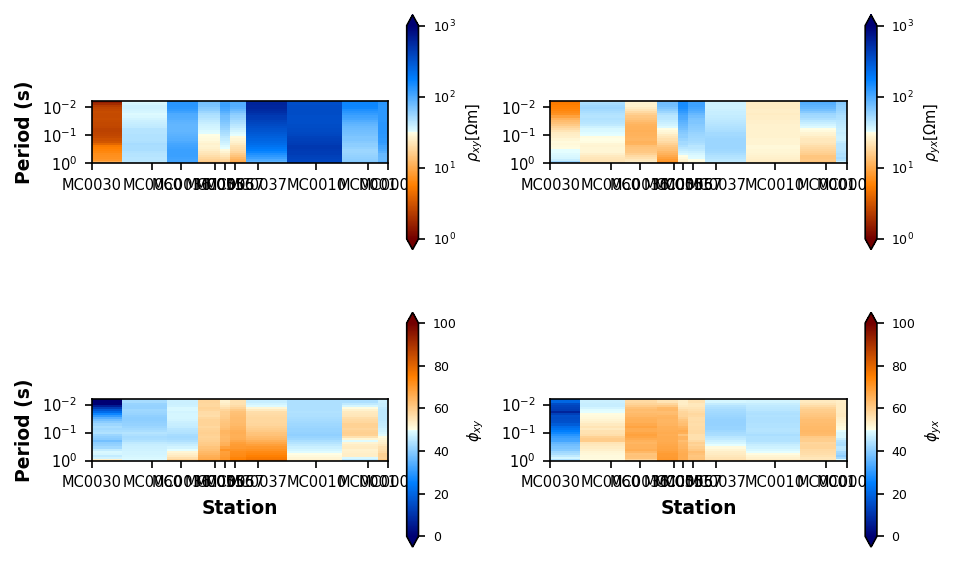

In [145]:
rpp_plot = profile_mt_data.plot_resistivity_phase_pseudosections(y_stretch=1200)

Plotting PlotPhaseTensorPseudoSection

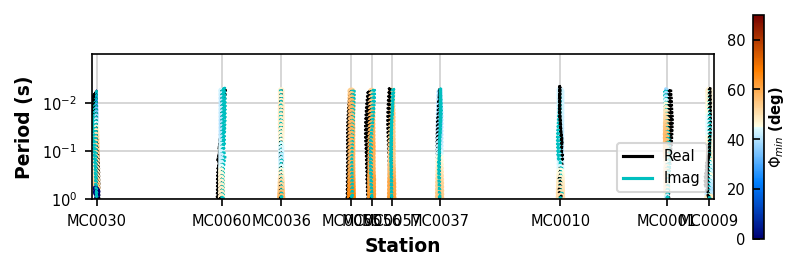

In [146]:
profile_mt_data.plot_phase_tensor_pseudosection(x_stretch=15, plot_tipper="yri")

## Análisis de direccionalidad

### Strike electromagnético para todos los periodos

26:03:17T14:55:31 | INFO | line:861 |mtpy.imaging.plot_strike | _plot_all_periods | Note: North is assumed to be 0 and the strike angle is measured clockwise positive.


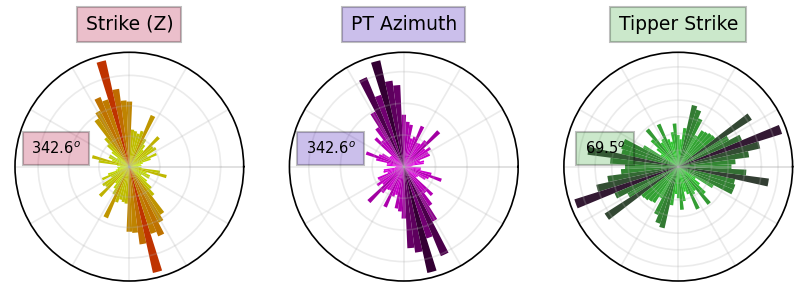

In [147]:
strike_plot = mtd.plot_strike()

### Strike electromagnético por periodos

Strike statistics for invariant period range 0.001 to 0.01 (s) median=328.1 mode=357.5 mean=244.9
Strike statistics for pt period range 0.001 to 0.01 (s) median=329.5 mode=352.6 mean=244.6
Strike statistics for tipper period range 0.001 to 0.01 (s) median=51.7 mode=114.2 mean=22.9
Strike statistics for invariant period range 0.01 to 0.1 (s) median=319.2 mode=342.6 mean=214.4
Strike statistics for pt period range 0.01 to 0.1 (s) median=321.0 mode=342.6 mean=218.3
Strike statistics for tipper period range 0.01 to 0.1 (s) median=38.5 mode=69.5 mean=11.1
Strike statistics for invariant period range 0.1 to 1 (s) median=292.1 mode=342.6 mean=213.2
Strike statistics for pt period range 0.1 to 1 (s) median=290.6 mode=332.7 mean=209.7
Strike statistics for tipper period range 0.1 to 1 (s) median=30.5 mode=19.9 mean=21.2
26:03:17T14:55:51 | INFO | line:765 |mtpy.imaging.plot_strike | _plot_per_period | Note: North is assumed to be 0 and the strike angle is measuredclockwise positive.


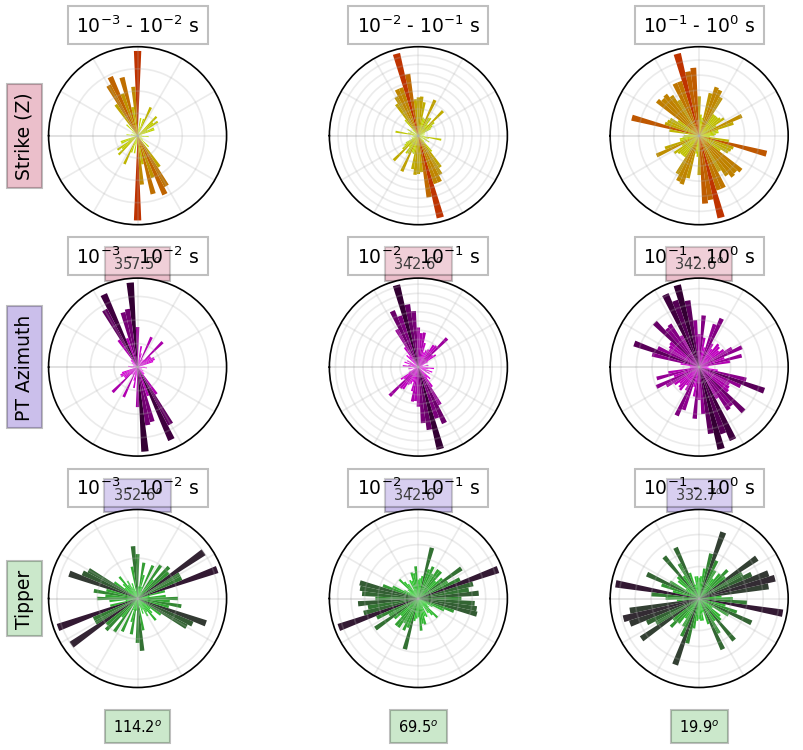

In [148]:
trike_plot_per_decade = mtd.plot_strike(plot_type=1, print_stats=True)

Strike statistics for invariant period range 0.001 to 0.01 (s) median=328.1 mode=357.5 mean=244.9
Strike statistics for pt period range 0.001 to 0.01 (s) median=329.5 mode=352.6 mean=244.6
Strike statistics for tipper period range 0.001 to 0.01 (s) median=51.7 mode=114.2 mean=22.9
Strike statistics for invariant period range 0.01 to 0.1 (s) median=319.2 mode=342.6 mean=214.4
Strike statistics for pt period range 0.01 to 0.1 (s) median=321.0 mode=342.6 mean=218.3
Strike statistics for tipper period range 0.01 to 0.1 (s) median=38.5 mode=69.5 mean=11.1
Strike statistics for invariant period range 0.1 to 1 (s) median=292.1 mode=342.6 mean=213.2
Strike statistics for pt period range 0.1 to 1 (s) median=290.6 mode=332.7 mean=209.7
Strike statistics for tipper period range 0.1 to 1 (s) median=30.5 mode=19.9 mean=21.2
26:03:17T14:55:55 | INFO | line:765 |mtpy.imaging.plot_strike | _plot_per_period | Note: North is assumed to be 0 and the strike angle is measuredclockwise positive.


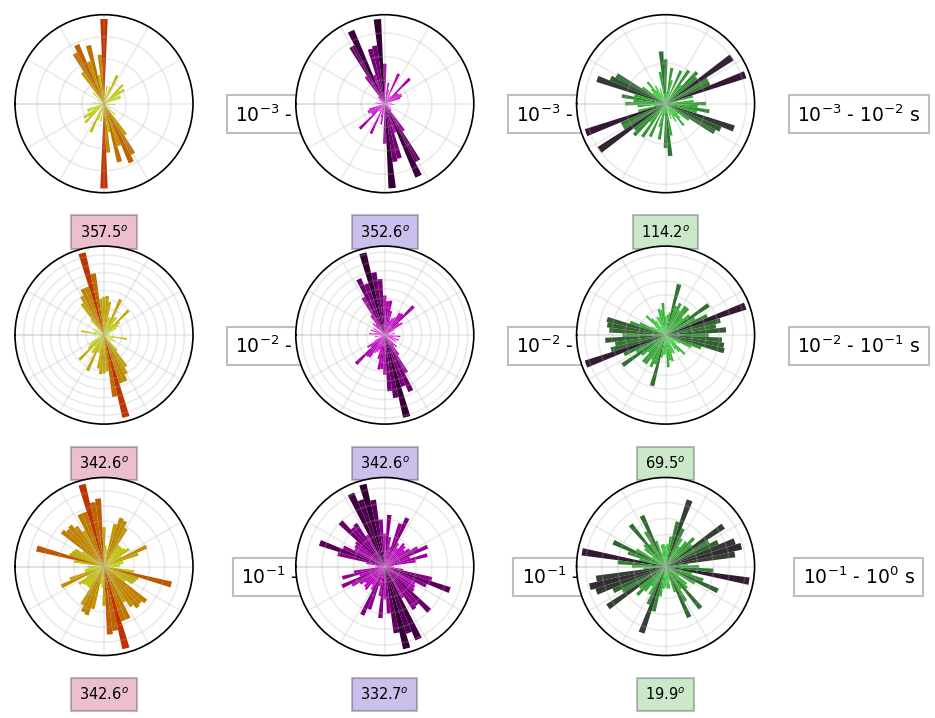

In [149]:
trike_plot_per_decade.plot_orientation = "vertical"
trike_plot_per_decade.redraw_plot()

In [150]:
datosrotate = profile_mt_data.copy() # Hacer una copia de los datos interpolados del perfil

In [151]:
# Rotar los datos

datosrotate.rotate(-56)

26:03:17T14:56:01 | INFO | line:292 |mtpy.core.mt | rotate | Rotated transfer function by: -56.000 degrees clockwise in reference frame NED.
26:03:17T14:56:02 | INFO | line:292 |mtpy.core.mt | rotate | Rotated transfer function by: -56.000 degrees clockwise in reference frame NED.
26:03:17T14:56:04 | INFO | line:292 |mtpy.core.mt | rotate | Rotated transfer function by: -56.000 degrees clockwise in reference frame NED.
26:03:17T14:56:05 | INFO | line:292 |mtpy.core.mt | rotate | Rotated transfer function by: -56.000 degrees clockwise in reference frame NED.
26:03:17T14:56:06 | INFO | line:292 |mtpy.core.mt | rotate | Rotated transfer function by: -56.000 degrees clockwise in reference frame NED.
26:03:17T14:56:07 | INFO | line:292 |mtpy.core.mt | rotate | Rotated transfer function by: -56.000 degrees clockwise in reference frame NED.
26:03:17T14:56:08 | INFO | line:292 |mtpy.core.mt | rotate | Rotated transfer function by: -56.000 degrees clockwise in reference frame NED.
26:03:17T14:5

26:03:17T14:56:17 | INFO | line:861 |mtpy.imaging.plot_strike | _plot_all_periods | Note: North is assumed to be 0 and the strike angle is measured clockwise positive.


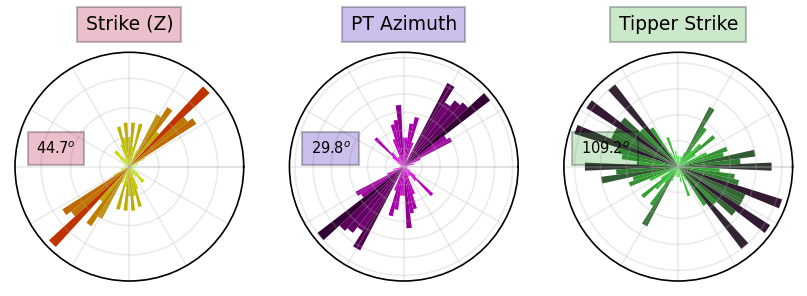

Plotting PlotStrike

In [152]:
datosrotate.plot_strike()